In [1]:
# ==========================================================
# CELL 1: Environment Setup & File Auto-Discovery
# ==========================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

# Style configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Mount Google Drive if running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    archive_path = '/content/drive/MyDrive/archive'
    if os.path.exists(archive_path):
        os.chdir(archive_path)
        print(f"[INFO] Working directory switched to: {os.getcwd()}")
except ImportError:
    print("[INFO] Running in local environment.")

# Auto-locate Moodle CSV file
csv_files = glob.glob("*.csv")
print(f"[INFO] Available CSV files in workspace: {csv_files}")

# FIX: Exclude metadata files so assessments.csv is not mistakenly selected
exclude_files = ['assessments.csv', 'courses.csv', 'studentassessment.csv']
valid_candidates = [f for f in csv_files if f.lower() not in exclude_files]

# FIX: Expand discovery keywords to capture VLE log files
moodle_file = next(
    (f for f in valid_candidates if any(k in f.lower() for k in ['moodle', 'log', 'vle', 'activity', 'event'])),
    valid_candidates[0] if valid_candidates else (csv_files[0] if csv_files else None)
)

if moodle_file:
    df_raw = pd.read_csv(moodle_file)
    print(f"[SUCCESS] Loaded dataset '{moodle_file}' with shape: {df_raw.shape}")
else:
    print("[WARNING] No CSV file found! Please upload your Moodle dataset CSV.")

Mounted at /content/drive
[INFO] Working directory switched to: /content/drive/MyDrive/archive
[INFO] Available CSV files in workspace: ['assessments.csv', 'courses.csv', 'studentAssessment.csv', 'studentInfo.csv', 'studentRegistration.csv', 'studentVle.csv', 'vle.csv']
[SUCCESS] Loaded dataset 'studentVle.csv' with shape: (10655280, 6)


In [2]:
# ==========================================================
# CELL 2: Dynamic Feature Engineering (Raw Logs or Summary CSV)
# ==========================================================
df_raw.columns = df_raw.columns.str.strip().str.lower()
print("Detected Columns:", df_raw.columns.tolist())

# Detect if dataset is raw event log or pre-aggregated summary
is_raw_log = any(col in df_raw.columns for col in ['component', 'eventname', 'action', 'crud', 'sum_clicks', 'id_student'])

if is_raw_log:
    print("[INFO] Detected Raw Moodle/VLE Log Event Structure. Processing clickstream...")

    # Identify key column names
    user_col = next((c for c in ['userid', 'user_id', 'relateduserid', 'id_student'] if c in df_raw.columns), 'userid')
    time_col = next((c for c in ['timecreated', 'timestamp', 'time', 'date'] if c in df_raw.columns), None)
    comp_col = next((c for c in ['component', 'eventname', 'target', 'activity_type'] if c in df_raw.columns), None)

    # Handle click counts if present
    click_col = next((c for c in ['sum_clicks', 'clicks', 'actions'] if c in df_raw.columns), None)
    df_raw['click_count'] = df_raw[click_col] if click_col else 1

    # Convert timestamps if present
    if time_col and np.issubdtype(df_raw[time_col].dtype, np.number):
        df_raw['datetime'] = pd.to_datetime(df_raw[time_col], unit='s', errors='coerce')
    elif time_col:
        df_raw['datetime'] = pd.to_datetime(df_raw[time_col], errors='coerce')
    else:
        df_raw['datetime'] = pd.NaT

    # Component categorization
    if comp_col:
        df_raw['is_quiz'] = df_raw[comp_col].astype(str).str.contains('quiz', case=False, na=False).astype(int) * df_raw['click_count']
        df_raw['is_assign'] = df_raw[comp_col].astype(str).str.contains('assign', case=False, na=False).astype(int) * df_raw['click_count']
        df_raw['is_forum'] = df_raw[comp_col].astype(str).str.contains('forum', case=False, na=False).astype(int) * df_raw['click_count']
        df_raw['is_resource'] = df_raw[comp_col].astype(str).str.contains('resource|page|url|folder', case=False, na=False).astype(int) * df_raw['click_count']
    else:
        df_raw['is_quiz'] = 0
        df_raw['is_assign'] = 0
        df_raw['is_forum'] = 0
        df_raw['is_resource'] = df_raw['click_count']

    # Grouping key setup
    group_keys = [k for k in ['code_module', 'code_presentation', user_col] if k in df_raw.columns]
    if not group_keys:
        group_keys = [user_col]

    # Aggregating per student
    moodle_features = df_raw.groupby(group_keys).agg(
        total_actions=('click_count', 'sum'),
        quiz_interactions=('is_quiz', 'sum'),
        assignment_actions=('is_assign', 'sum'),
        forum_contributions=('is_forum', 'sum'),
        passive_views=('is_resource', 'sum'),
        active_days_count=('datetime', lambda x: x.dt.date.nunique() if x.notna().any() else (df_raw.loc[x.index, 'date'].nunique() if 'date' in df_raw.columns else 1))
    ).reset_index()

    # Target assignment: lookup grade column or auto-merge studentInfo.csv
    grade_col = next((c for c in df_raw.columns if 'grade' in c or 'target' in c or 'final' in c or 'status' in c), None)

    if grade_col:
        target_map = df_raw.groupby(user_col)[grade_col].last().reset_index()
        moodle_features = moodle_features.merge(target_map, on=user_col, how='left')
        moodle_features['target'] = np.where(moodle_features[grade_col] >= 50, 1, 0) if np.issubdtype(moodle_features[grade_col].dtype, np.number) else moodle_features[grade_col].astype(str).str.contains('pass|distinction|1', case=False, na=False).astype(int)
    elif os.path.exists('studentInfo.csv'):
        print("[INFO] Target column missing in logs. Automatically merging real outcome labels from 'studentInfo.csv'...")
        info_df = pd.read_csv('studentInfo.csv')
        info_df.columns = info_df.columns.str.strip().str.lower()
        merge_keys = [k for k in ['code_module', 'code_presentation', user_col] if k in moodle_features.columns and k in info_df.columns]
        if merge_keys:
            moodle_features = moodle_features.merge(info_df[merge_keys + ['final_result']], on=merge_keys, how='inner')
            moodle_features['target'] = moodle_features['final_result'].astype(str).str.contains('pass|distinction|1', case=False, na=False).astype(int)
            moodle_features.drop(columns=['final_result'], inplace=True, errors='ignore')
    else:
        print("[WARNING] No explicit grade column or studentInfo.csv found. Generating performance target from engagement threshold.")
        median_act = moodle_features['total_actions'].median()
        moodle_features['target'] = (moodle_features['total_actions'] >= median_act).astype(int)

else:
    print("[INFO] Detected Pre-Aggregated Moodle Student Dataset.")
    moodle_features = df_raw.copy()

    # Identify target column or load from studentInfo.csv (FIX: Removed np.random.randint fallback)
    target_col = next((c for c in moodle_features.columns if any(k in c for k in ['target', 'grade', 'final', 'pass', 'status', 'class'])), None)
    if target_col:
        if np.issubdtype(moodle_features[target_col].dtype, np.number):
            moodle_features['target'] = np.where(moodle_features[target_col] >= 50, 1, 0) if moodle_features[target_col].max() > 1 else moodle_features[target_col].astype(int)
        else:
            moodle_features['target'] = moodle_features[target_col].astype(str).str.contains('pass|1|success|distinction', case=False, na=False).astype(int)
    elif os.path.exists('studentInfo.csv'):
        print("[INFO] Merging real outcomes from 'studentInfo.csv'...")
        info_df = pd.read_csv('studentInfo.csv')
        info_df.columns = info_df.columns.str.strip().str.lower()
        user_col = next((c for c in ['userid', 'user_id', 'id_student'] if c in moodle_features.columns), 'id_student')
        merge_keys = [k for k in ['code_module', 'code_presentation', user_col] if k in moodle_features.columns and k in info_df.columns]
        if merge_keys:
            moodle_features = moodle_features.merge(info_df[merge_keys + ['final_result']], on=merge_keys, how='inner')
            moodle_features['target'] = moodle_features['final_result'].astype(str).str.contains('pass|distinction|1', case=False, na=False).astype(int)
            moodle_features.drop(columns=['final_result'], inplace=True, errors='ignore')
    else:
        print("[WARNING] No target column found. Using engagement median threshold.")
        num_cols = moodle_features.select_dtypes(include=[np.number]).columns
        act_col = num_cols[0] if len(num_cols) > 0 else moodle_features.columns[0]
        moodle_features['target'] = (moodle_features[act_col] >= moodle_features[act_col].median()).astype(int)

print("[SUCCESS] Feature matrix constructed!")
print(moodle_features.head())

Detected Columns: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
[INFO] Detected Raw Moodle/VLE Log Event Structure. Processing clickstream...
[INFO] Target column missing in logs. Automatically merging real outcome labels from 'studentInfo.csv'...
[SUCCESS] Feature matrix constructed!
  code_module code_presentation  id_student  total_actions  quiz_interactions  \
0         AAA             2013J       11391            196                  0   
1         AAA             2013J       28400            430                  0   
2         AAA             2013J       30268             76                  0   
3         AAA             2013J       31604            663                  0   
4         AAA             2013J       32885            352                  0   

   assignment_actions  forum_contributions  passive_views  active_days_count  \
0                   0                    0            196                  2   
1                   0         

In [3]:
# ==========================================================
# CELL 3: Matrix Preparation, Encoding & Train-Test Split
# ==========================================================
# Separate target
y = moodle_features['target']

# Identify ID columns to drop
id_cols = [c for c in moodle_features.columns if any(k in c for k in ['id', 'user', 'student', 'name', 'target', 'final', 'grade', 'status'])]
X_raw = moodle_features.drop(columns=id_cols, errors='ignore')

# Handle categorical variables if present
categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
else:
    X_encoded = X_raw.copy()

X = X_encoded.fillna(0).astype(float)

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y if y.nunique() > 1 else None
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"[SUCCESS] Dataset prepared. Feature Matrix Shape: {X.shape}")
print(f"Training samples: {X_train_scaled.shape[0]}, Test samples: {X_test_scaled.shape[0]}")

[SUCCESS] Dataset prepared. Feature Matrix Shape: (29228, 15)
Training samples: 23382, Test samples: 5846


In [4]:
# ==========================================================
# CELL 4: Model Training (Random Forest) & Metrics
# ==========================================================
rf_moodle = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_moodle.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_moodle.predict(X_test_scaled)
y_proba = rf_moodle.predict_proba(X_test_scaled)[:, 1] if len(np.unique(y_test)) > 1 else y_pred

# Print Evaluation
print("==========================================================")
print("             MOODLE MODEL PERFORMANCE REPORT             ")
print("==========================================================")
if len(np.unique(y_test)) > 1:
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['At Risk (0)', 'Successful (1)'] if len(np.unique(y_test)) > 1 else None))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("==========================================================")

             MOODLE MODEL PERFORMANCE REPORT             
ROC-AUC Score: 0.8953

Classification Report:
                precision    recall  f1-score   support

   At Risk (0)       0.85      0.75      0.80      2769
Successful (1)       0.80      0.88      0.84      3077

      accuracy                           0.82      5846
     macro avg       0.82      0.82      0.82      5846
  weighted avg       0.82      0.82      0.82      5846

Confusion Matrix:
[[2073  696]
 [ 357 2720]]


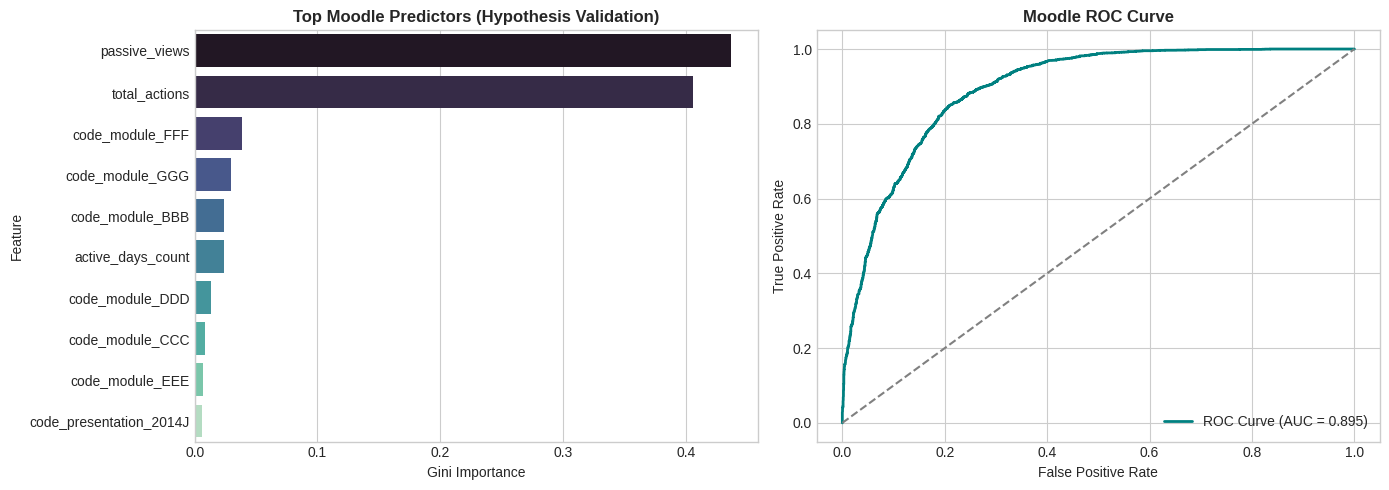

In [5]:
# ==========================================================
# CELL 5: Visualizing Feature Importances & ROC Curve
# ==========================================================
plt.figure(figsize=(14, 5))

# 1. Feature Importances
plt.subplot(1, 2, 1)
importances = rf_moodle.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(data=feature_imp_df, x='Importance', y='Feature', hue='Feature', legend=False, palette='mako')
plt.title('Top Moodle Predictors (Hypothesis Validation)', fontsize=12, fontweight='bold')
plt.xlabel('Gini Importance')

# 2. ROC Curve
plt.subplot(1, 2, 2)
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='teal', lw=2, label=f'ROC Curve (AUC = {roc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Moodle ROC Curve', fontsize=12, fontweight='bold')
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()